# Model 1: Regularized Bias Baseline

This notebook builds a simple rating prediction baseline. It splits the ratings into train/test data, learns user and item effects from the training set, and evaluates the predictions with MAE and RMSE.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
import os
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 12})


## Load Ratings Data

The notebook uses the same data path setup as the exploration notebook.


In [2]:
project_root = Path.cwd()

env_data_dir = os.getenv('DATA_DIR')
local_cfg_path = project_root / 'paths.local.json'

if env_data_dir:
    data_dir = Path(env_data_dir).expanduser()
elif local_cfg_path.exists():
    data_dir = Path(json.loads(local_cfg_path.read_text())['data_dir']).expanduser()
else:
    # From Untitled/Vet_Recc, the dataset folder is two levels above this notebook.
    candidate = project_root / '15_Veterinarian_Recommendation'
    if not candidate.exists():
        candidate = project_root.parent.parent / '15_Veterinarian_Recommendation'
    data_dir = candidate

ratings_path = data_dir / 'ratings_Pet_Supplies.csv'
print('Using data directory:', data_dir)
print('Ratings path:', ratings_path)

Using data directory: /Users/fatihtekin/Desktop/MAI/Data Analytics/Project 2/15_Veterinarian_Recommendation
Ratings path: /Users/fatihtekin/Desktop/MAI/Data Analytics/Project 2/15_Veterinarian_Recommendation/ratings_Pet_Supplies.csv


In [3]:
ratings_df = pd.read_csv(
    ratings_path,
    header=None,
    names=['user_id', 'asin', 'rating', 'timestamp']
)

ratings_df.info()
ratings_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1235316 entries, 0 to 1235315
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   user_id    1235316 non-null  str    
 1   asin       1235316 non-null  str    
 2   rating     1235316 non-null  float64
 3   timestamp  1235316 non-null  int64  
dtypes: float64(1), int64(1), str(2)
memory usage: 37.7 MB


,user_id,asin,rating,timestamp
0,A3PG0KS1YE8MR4,0615553605,5.0,1354838400
1,A363P047LR5XI6,0615553605,4.0,1373932800
2,ABZ8CQXD42H4,0615553605,1.0,1386028800
3,A3J8QW1MV1OP01,0615583474,5.0,1347321600
4,A3ISA8Z0NB0ILH,0615583474,5.0,1358899200


## Why This Model

The data is very sparse, so many users and items have only a few ratings. This model keeps the prediction simple:

```text
predicted_rating = global_mean + item_bias + user_bias
```

The biases are regularized, so users/items with little evidence stay close to the global average. The test ratings are hidden during prediction and used only for evaluation.


In [4]:
# Use only the columns needed for rating prediction.
ratings_model_df = ratings_df[['user_id', 'asin', 'rating']].copy()

# Random 80/20 split. The test ratings are treated as hidden during prediction.
train_df = ratings_model_df.sample(frac=0.80, random_state=42)
test_df = ratings_model_df.drop(train_df.index)

print(f"Training ratings: {len(train_df):,}")
print(f"Test ratings    : {len(test_df):,}")
print(f"Train users     : {train_df['user_id'].nunique():,}")
print(f"Train items     : {train_df['asin'].nunique():,}")
print(f"Test users unseen in train: {(~test_df['user_id'].isin(train_df['user_id'])).sum():,} rows")
print(f"Test items unseen in train: {(~test_df['asin'].isin(train_df['asin'])).sum():,} rows")

Training ratings: 988,253
Test ratings    : 247,063
Train users     : 628,369
Train items     : 94,206
Test users unseen in train: 117,795 rows
Test items unseen in train: 9,889 rows


## Train the Bias Model

The regularization value controls how much we shrink user and item effects. This prevents one or two ratings from creating overly strong biases.


In [5]:
regularization = 10

global_mean = train_df['rating'].mean()

# Item bias: how much each item tends to be rated above/below the global mean.
item_residuals = train_df.assign(centered_rating=train_df['rating'] - global_mean)
item_bias = (
    item_residuals
    .groupby('asin')
    .agg(residual_sum=('centered_rating', 'sum'), rating_count=('rating', 'count'))
)
item_bias['item_bias'] = item_bias['residual_sum'] / (item_bias['rating_count'] + regularization)

# User bias: how generous/strict each user is after accounting for item bias.
train_with_item_bias = train_df.join(item_bias['item_bias'], on='asin')
train_with_item_bias['item_bias'] = train_with_item_bias['item_bias'].fillna(0)
train_with_item_bias['user_residual'] = (
    train_with_item_bias['rating']
    - global_mean
    - train_with_item_bias['item_bias']
)

user_bias = (
    train_with_item_bias
    .groupby('user_id')
    .agg(residual_sum=('user_residual', 'sum'), rating_count=('rating', 'count'))
)
user_bias['user_bias'] = user_bias['residual_sum'] / (user_bias['rating_count'] + regularization)

print(f"Global mean rating: {global_mean:.4f}")
print(f"Regularization strength: {regularization}")
print()
print('Item bias summary:')
print(item_bias['item_bias'].describe())
print()
print('User bias summary:')
print(user_bias['user_bias'].describe())

Global mean rating: 4.1106
Regularization strength: 10

Item bias summary:
count    94206.000000
mean        -0.010971
std          0.238477
min         -2.622468
25%         -0.102454
50%          0.071899
75%          0.094684
max          0.807577
Name: item_bias, dtype: float64

User bias summary:
count    628369.000000
mean         -0.002298
std           0.135490
min          -2.041444
25%          -0.068581
50%           0.042830
75%           0.078497
max           0.911913
Name: user_bias, dtype: float64


## Predict and Evaluate

For each test row, the model combines the global mean with the learned user and item biases. If a user or item was not seen during training, its bias is set to zero. Predictions are clipped to the valid rating range from 1 to 5.


In [6]:
def predict_bias_model(df, global_mean, item_bias, user_bias):
    pred_df = df[['user_id', 'asin', 'rating']].copy()
    pred_df = pred_df.join(item_bias['item_bias'], on='asin')
    pred_df = pred_df.join(user_bias['user_bias'], on='user_id')

    pred_df['item_bias'] = pred_df['item_bias'].fillna(0)
    pred_df['user_bias'] = pred_df['user_bias'].fillna(0)
    pred_df['prediction'] = (
        global_mean
        + pred_df['item_bias']
        + pred_df['user_bias']
    ).clip(lower=1, upper=5)

    return pred_df

baseline_predictions = predict_bias_model(test_df, global_mean, item_bias, user_bias)

errors = baseline_predictions['rating'] - baseline_predictions['prediction']
mae = errors.abs().mean()
rmse = np.sqrt((errors ** 2).mean())

print('Regularized Bias Baseline Performance')
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

baseline_predictions[['user_id', 'asin', 'rating', 'prediction', 'item_bias', 'user_bias']].head(10)

Regularized Bias Baseline Performance
MAE : 0.9747
RMSE: 1.2422


,user_id,asin,rating,prediction,item_bias,user_bias
8,AK5D5XJ7OHNFG,0615583474,5.0,4.476843,0.366210,0.000000
21,A1KQP4FOU6OJCM,0972585419,3.0,3.275593,-0.573755,-0.261285
23,A2S46S9V4B8AGG,0972585419,1.0,3.536878,-0.573755,0.000000
27,AD4ZLC6ZIZKYH,0972585419,3.0,3.536878,-0.573755,0.000000
37,A1GZOGZBXWW5ZH,0975412809,5.0,4.471558,0.360925,0.000000
42,ARAS95O6YKHE8,0975412809,5.0,4.471558,0.360925,0.000000
46,A2GW7O3PDT2IQ9,0975412809,5.0,4.471558,0.360925,0.000000
55,A162Q8432V42IS,0975412809,5.0,4.288934,0.360925,-0.182624
56,A1866RR8C3YS5P,0975412809,3.0,4.471558,0.360925,0.000000
59,ALZDKXS72V0XB,0975412809,5.0,4.471558,0.360925,0.000000


#### Observation
This model is a useful baseline because it captures product-level rating tendency and limited user-level behavior. Since most users have little history, item bias is expected to be more reliable than user bias.


In [7]:
# Compare against a simpler global-mean-only baseline.
global_only_pred = np.full(shape=len(test_df), fill_value=global_mean)
global_only_errors = test_df['rating'] - global_only_pred
global_only_mae = global_only_errors.abs().mean()
global_only_rmse = np.sqrt((global_only_errors ** 2).mean())

model_1_results = pd.DataFrame({
    'model': ['Global mean baseline', 'Regularized bias baseline'],
    'MAE': [global_only_mae, mae],
    'RMSE': [global_only_rmse, rmse]
})

model_1_results

,model,MAE,RMSE
0,Global mean baseline,1.070809,1.332165
1,Regularized bias baseline,0.974651,1.242186


## Diagnostic Analysis

The overall MAE/RMSE shows model performance, but the diagnostics show where the model works and where it struggles.


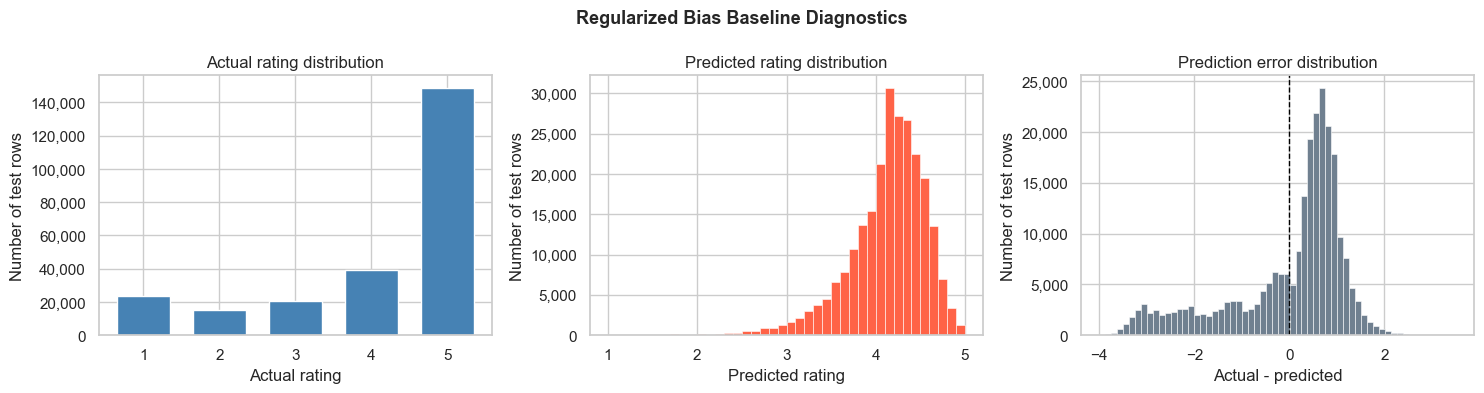

Mean error / bias: -0.0178
Median absolute error: 0.7561
Predictions clipped at 1: 0
Predictions clipped at 5: 384


In [8]:
diagnostics_df = baseline_predictions.copy()
diagnostics_df['error'] = diagnostics_df['rating'] - diagnostics_df['prediction']
diagnostics_df['absolute_error'] = diagnostics_df['error'].abs()
diagnostics_df['squared_error'] = diagnostics_df['error'] ** 2

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Actual vs predicted rating distribution
rating_counts = diagnostics_df['rating'].value_counts().sort_index()
pred_bins = np.linspace(1, 5, 41)
axes[0].bar(rating_counts.index, rating_counts.values, width=0.7, color='steelblue', edgecolor='white')
axes[0].set_title('Actual rating distribution')
axes[0].set_xlabel('Actual rating')
axes[0].set_ylabel('Number of test rows')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].hist(diagnostics_df['prediction'], bins=pred_bins, color='tomato', edgecolor='white', linewidth=0.4)
axes[1].set_title('Predicted rating distribution')
axes[1].set_xlabel('Predicted rating')
axes[1].set_ylabel('Number of test rows')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[2].hist(diagnostics_df['error'], bins=60, color='slategray', edgecolor='white', linewidth=0.4)
axes[2].axvline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Prediction error distribution')
axes[2].set_xlabel('Actual - predicted')
axes[2].set_ylabel('Number of test rows')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Regularized Bias Baseline Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean error / bias: {diagnostics_df['error'].mean():+.4f}")
print(f"Median absolute error: {diagnostics_df['absolute_error'].median():.4f}")
print(f"Predictions clipped at 1: {(diagnostics_df['prediction'] == 1).sum():,}")
print(f"Predictions clipped at 5: {(diagnostics_df['prediction'] == 5).sum():,}")

### Performance by True Rating

The ratings are mostly high, so overall error can hide weak performance on low ratings. This table checks errors separately for each true rating value.


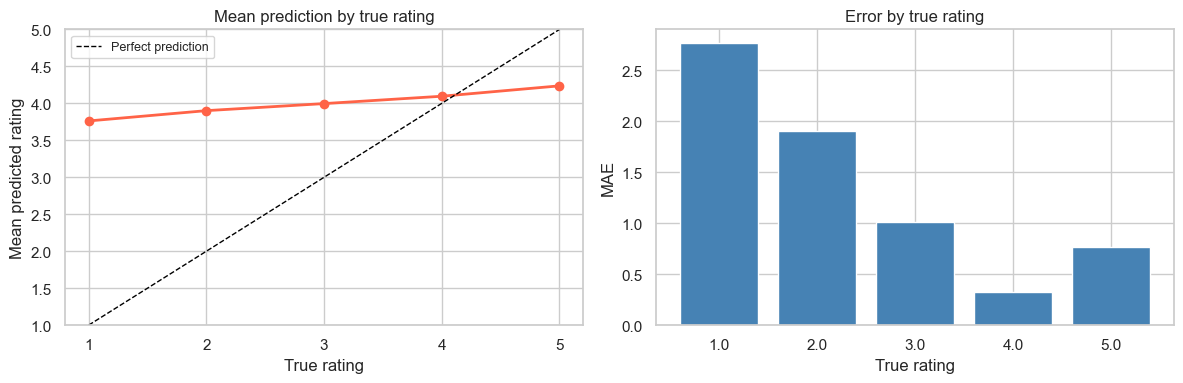

,rating,test_rows,mean_prediction,MAE,RMSE
0,1.0,23612,3.762115,2.762115,2.815865
1,2.0,14841,3.901326,1.901657,1.956461
2,3.0,20838,3.996707,1.009695,1.080949
3,4.0,38982,4.096212,0.327191,0.409129
4,5.0,148790,4.236749,0.763251,0.845328


In [9]:
performance_by_rating = (
    diagnostics_df
    .groupby('rating')
    .agg(
        test_rows=('rating', 'count'),
        mean_prediction=('prediction', 'mean'),
        MAE=('absolute_error', 'mean'),
        RMSE=('squared_error', lambda x: np.sqrt(x.mean()))
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(performance_by_rating['rating'], performance_by_rating['mean_prediction'], marker='o', linewidth=2, color='tomato')
axes[0].plot([1, 5], [1, 5], linestyle='--', color='black', linewidth=1, label='Perfect prediction')
axes[0].set_xlabel('True rating')
axes[0].set_ylabel('Mean predicted rating')
axes[0].set_title('Mean prediction by true rating')
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].set_ylim(1, 5)
axes[0].legend(fontsize=9)

axes[1].bar(performance_by_rating['rating'].astype(str), performance_by_rating['MAE'], color='steelblue', edgecolor='white')
axes[1].set_xlabel('True rating')
axes[1].set_ylabel('MAE')
axes[1].set_title('Error by true rating')

plt.tight_layout()
plt.show()

performance_by_rating

### Seen vs. Unseen Users and Items

If a test user or item was not present in training, the model cannot learn its bias. This breakdown shows how much that affects error.


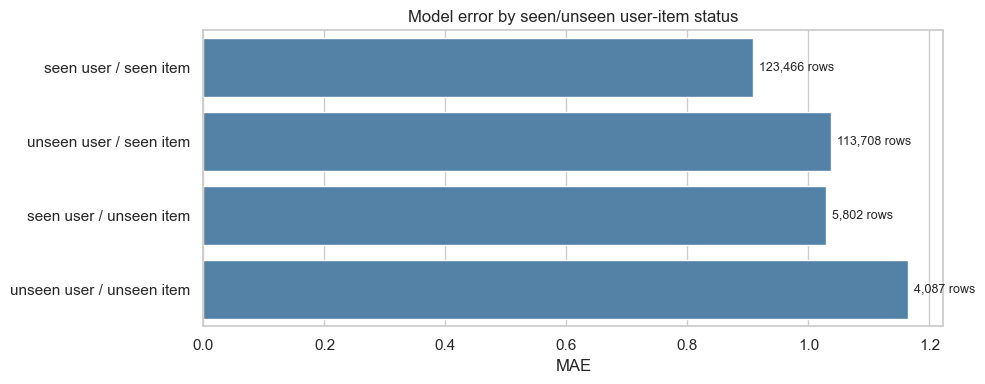

,status,test_rows,share_of_test,mean_rating,mean_prediction,MAE,RMSE
0,seen user / seen item,123466,0.499735,4.189745,4.158522,0.907704,1.158751
1,unseen user / seen item,113708,0.460239,4.031036,4.097331,1.037781,1.317364
2,seen user / unseen item,5802,0.023484,4.084798,4.126659,1.028222,1.281703
3,unseen user / unseen item,4087,0.016542,3.996575,4.110633,1.164674,1.449004


In [10]:
diagnostics_df['user_seen_in_train'] = diagnostics_df['user_id'].isin(train_df['user_id'])
diagnostics_df['item_seen_in_train'] = diagnostics_df['asin'].isin(train_df['asin'])

seen_breakdown = (
    diagnostics_df
    .assign(
        user_status=lambda x: np.where(x['user_seen_in_train'], 'seen user', 'unseen user'),
        item_status=lambda x: np.where(x['item_seen_in_train'], 'seen item', 'unseen item'),
        status=lambda x: x['user_status'] + ' / ' + x['item_status']
    )
    .groupby('status')
    .agg(
        test_rows=('rating', 'count'),
        share_of_test=('rating', lambda x: len(x) / len(diagnostics_df)),
        mean_rating=('rating', 'mean'),
        mean_prediction=('prediction', 'mean'),
        MAE=('absolute_error', 'mean'),
        RMSE=('squared_error', lambda x: np.sqrt(x.mean()))
    )
    .sort_values('test_rows', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=seen_breakdown, y='status', x='MAE', ax=ax, color='steelblue')
ax.set_xlabel('MAE')
ax.set_ylabel('')
ax.set_title('Model error by seen/unseen user-item status')
for i, row in seen_breakdown.iterrows():
    ax.text(row['MAE'] + 0.01, i, f"{row['test_rows']:,} rows", va='center', fontsize=9)
plt.tight_layout()
plt.show()

seen_breakdown

### Bias Distributions

These plots show the spread of learned item and user effects. A wider item-bias distribution means item-level differences carry more signal.


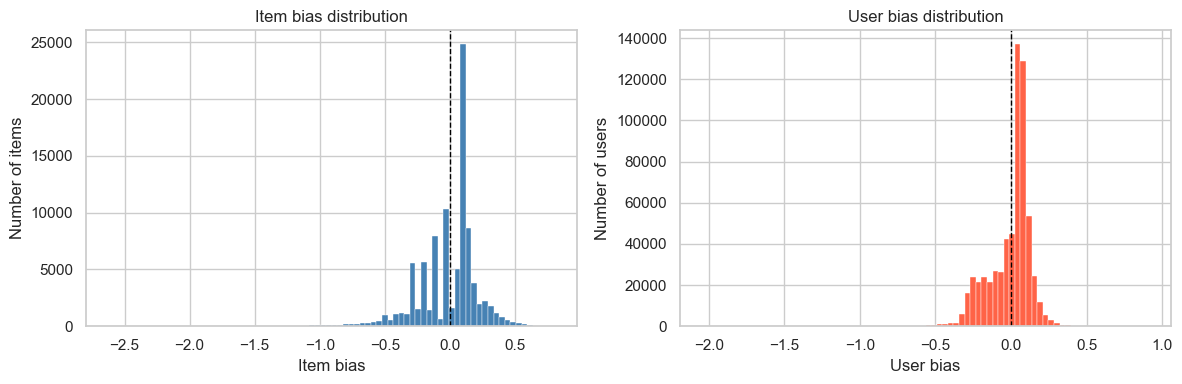

Item bias std: 0.2385
User bias std: 0.1355


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(item_bias['item_bias'], bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Item bias distribution')
axes[0].set_xlabel('Item bias')
axes[0].set_ylabel('Number of items')

axes[1].hist(user_bias['user_bias'], bins=80, color='tomato', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('User bias distribution')
axes[1].set_xlabel('User bias')
axes[1].set_ylabel('Number of users')

plt.tight_layout()
plt.show()

print(f"Item bias std: {item_bias['item_bias'].std():.4f}")
print(f"User bias std: {user_bias['user_bias'].std():.4f}")

#### Model 1 Takeaway

The model improves over predicting the same average rating for every row, but it is still limited by sparse user histories. It works best as a stable baseline for comparing later models.
